In [1]:
#EDSL has a cache directory that stores the responses from the LLM. Since we need new responses everytime, we need to clear the cache.    
import shutil
import os

# Path to the .edsl_cache directory
cache_dir = '.edsl_cache'

# Check if the directory exists
if os.path.exists(cache_dir):
    # Remove the directory and its contents
    shutil.rmtree(cache_dir)


In [2]:
from edsl import (
    QuestionFreeText,
    QuestionMultipleChoice,
    QuestionNumerical,
    Scenario,
    Survey,
    Agent,
    AgentList,
    Model,
)
import os
import random
import csv
import pandas as pd
import goodfire


In [3]:
# Initialize Goodfire client
client = goodfire.Client(os.getenv("GOODFIRE_API_KEY"))
# Create a Goodfire variant object instead of just using a string
base_variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")


In [4]:
# Base Experiment Class
class SocialExperiment:
    def __init__(self, name, agents, model):
        self.name = name
        self.agents = agents
        self.model = model
        self.questions = []
        self.variant = goodfire.Variant(
            "meta-llama/Llama-3.3-70B-Instruct"
        )  # Initialize with base variant

    def setup(self):
        """Sets up the experiment by defining questions."""
        raise NotImplementedError

    def run(self, intervention=True):
        """Runs the experiment, optionally applying Goodfire interventions."""
        if intervention:
            self.model.parameters["controller"] = self.get_intervention()
            # For feature inspection, we need to apply the same controller to our variant
            controller_json = self.get_intervention()
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

            # Extract and apply features from controller JSON
            if "interventions" in controller_json:
                for intervention in controller_json["interventions"]:
                    if (
                        "features" in intervention
                        and "features" in intervention["features"]
                    ):
                        for feature_data in intervention["features"]["features"]:
                            # Create a feature object using feature search instead of direct creation
                            # This avoids needing to provide the index_in_sae
                            features = client.features.search(
                                feature_data["label"], model=self.variant, top_k=1
                            )
                            if features:
                                # Apply the feature with its value
                                self.variant.set(features[0], intervention["value"])
        else:
            self.model.parameters["controller"] = {}
            # Reset variant to base
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

        survey = Survey(self.questions)
        results = survey.by(self.agents).by(self.model).run(cache = False)
        return results

    def get_intervention(self):
        """Defines the Goodfire interventions for the experiment."""
        raise NotImplementedError

    def save_results(self, results, filename):
        """Saves results to a CSV file."""
        results.to_csv(filename)

    def print_results(self, results, experiment_name):
        """Prints formatted results for the experiment."""
        print(f"\n{experiment_name} Results:")
        print("--------------------")
        for question in self.questions:
            question_name = question.question_name
            ans = results.select(f"answer.{question_name}")
            com = results.select(f"comment.{question_name}_comment")
            print(f"\nQuestion: {question_name}")
            print(f"Answer: {ans}\nComment: {com}")

    def get_feature_activations(self, results, scenario_name, use_base_variant=False, activations_file=None):
        """Analyze feature activation for results and store in structured text file"""
        print(f"\n--- {scenario_name} Feature Activation ---")

        # Use base variant if requested (for baseline analysis)
        inspect_variant = base_variant if use_base_variant else self.variant

        # Get all question names from the result
        question_names = []
        for column in results.columns:
            if column.startswith("answer."):
                question_name = column.split(".")[1]
                if question_name not in question_names:
                    question_names.append(question_name)

        # Initialize activations data structure
        activations_data = {
            "scenario": scenario_name,
            "variant": "base" if use_base_variant else "intervention",
            "questions": {}
        }

        # Process each question
        for question_name in question_names:
            print(f"\nQuestion: {question_name}")

            # Get the user prompts and model responses
            try:
                # Select the relevant columns
                user_prompts = results.select(f"prompt.{question_name}_user_prompt")
                model_responses = results.select(
                    f"generated_tokens.{question_name}_generated_tokens"
                )

                # Convert to lists
                user_prompt_list = user_prompts.to_list()
                model_response_list = model_responses.to_list()

                # Check if we have data
                if user_prompt_list and model_response_list:
                    question_data = {
                        "total_responses": len(user_prompt_list),
                        "responses": []
                    }
                    
                    # Process ALL examples (no limit)
                    for i, (user_prompt, model_response) in enumerate(
                        zip(user_prompt_list, model_response_list)
                    ):
                        if user_prompt and model_response:
                            # Convert the user prompt from dict to string if necessary
                            if isinstance(user_prompt, dict) and "text" in user_prompt:
                                user_prompt = user_prompt["text"]

                            response_data = {
                                "response_id": i + 1,
                                "user_prompt": str(user_prompt),
                                "model_response": str(model_response),
                                "feature_activations": []
                            }

                            # Inspect feature activation
                            try:
                                inspector = client.features.inspect(
                                    [
                                        {"role": "user", "content": str(user_prompt)},
                                        {
                                            "role": "assistant",
                                            "content": str(model_response),
                                        },
                                    ],
                                    model=inspect_variant,  # Use the appropriate variant
                                )

                                # Store top activated features
                                for activation in inspector.top(k=10):
                                    response_data["feature_activations"].append({
                                        "feature_label": activation.feature.label,
                                        "activation_value": activation.activation
                                    })
                                    
                            except Exception as e:
                                response_data["error"] = f"Error analyzing features: {e}"
                            
                            question_data["responses"].append(response_data)
                    
                    activations_data["questions"][question_name] = question_data
                else:
                    print(f"No data found for question {question_name}")
            except Exception as e:
                print(f"Error processing data for question {question_name}: {e}")

        # Write activations to structured text file
        if activations_file:
            self._write_activations_to_file(activations_data, activations_file)

    def _write_activations_to_file(self, activations_data, filepath):
        """Write activations data to a structured text file"""
        with open(filepath, 'a', encoding='utf-8') as f:
            f.write(f"\n{'='*80}\n")
            f.write(f"SCENARIO: {activations_data['scenario']}\n")
            f.write(f"VARIANT: {activations_data['variant']}\n")
            f.write(f"{'='*80}\n\n")
            
            for question_name, question_data in activations_data['questions'].items():
                f.write(f"QUESTION: {question_name}\n")
                f.write(f"Total Responses: {question_data['total_responses']}\n")
                f.write(f"{'-'*60}\n\n")
                
                for response in question_data['responses']:
                    f.write(f"Response {response['response_id']}:\n")
                    f.write(f"User Prompt: {response['user_prompt']}\n")
                    f.write(f"Model Response: {response['model_response']}\n")
                    
                    if 'error' in response:
                        f.write(f"Error: {response['error']}\n")
                    else:
                        f.write("Top Feature Activations:\n")
                        for i, activation in enumerate(response['feature_activations'], 1):
                            f.write(f"  {i:2d}. {activation['feature_label']}: {activation['activation_value']:.6f}\n")
                    
                    f.write(f"\n{'-'*40}\n\n")
                
                f.write(f"\n{'='*60}\n\n")


In [5]:
# Ultimatum Game Experiment
class UltimatumGame(SocialExperiment):
    def __init__(self, name, agents, model, offer_amount=50):
        super().__init__(name, agents, model)
        self.offer_amount = offer_amount
        
    def setup(self):
        self.questions = []
        responder_text = (
            "ULTIMATUM GAME - RESPONDER\n\n"
            "You are participating in an economic decision-making experiment called the Ultimatum Game.\n\n"
            "Situation:\n"
            "1. Another participant (the proposer) was given 100 tokens (which have real monetary value).\n"
            f"2. The proposer has decided to offer you {self.offer_amount} tokens out of their 100 tokens.\n"
            f"3. If you accept this offer, you will receive {self.offer_amount} tokens, and the proposer will keep {100 - self.offer_amount} tokens.\n"
            "4. If you reject this offer, both of you will receive 0 tokens.\n\n"
            "Do you accept or reject this offer?"
        )
        self.questions.append(
            QuestionMultipleChoice(
                question_name="ultimatum_response",
                question_text=responder_text,
                question_options=[
                    "Accept",
                    "Reject",
                ],
            )
        )

    def get_intervention(self):
        return {'interventions': [{'mode': 'nudge',
   'features': {'features': [{'uuid': 'a239616d4dcf470497b32ad3500f0145',
      'label': 'Altruistic and selfless behavior or intentions',
      'index_in_sae': 31935,
      'max_activation_strength': 1}]},
   'value': 0.5}],
 'scopes': [],
 'name': 'controller__48491998',
 'nonzero_strength_threshold': None,
 'min_nudge_entropy': None,
 'max_nudge_entropy': None}


In [6]:
# Baseline agents (no special traits)
dummy_agents = AgentList(
    [
        Agent(name=f"Agent_{i}", traits={"subject_id": f"A{i}"}, instruction="")
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

# Fairness-focused agents (with prompting traits)
fairness_agents = AgentList(
    [
        Agent(
            name=f"Fairness_Agent_{i}", 
            traits={
                "subject_id": f"F{i}",
                "personality": "Altruistic and selfless behavior or intentions",
            }, 
            instruction=""
        )
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")


In [7]:
def run_ultimatum_experiments(baseline_agents, fairness_agents, model, start=10, end=90, step=5):
    results = []
    
    # Create results directory with timestamp
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    results_dir = f"mech_interp_games/ultimatum_game/results_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    
    # Create activations file path
    activations_file = os.path.join(results_dir, "feature_activations.txt")
    
    # Clear the activations file at the start
    with open(activations_file, 'w', encoding='utf-8') as f:
        f.write("FEATURE ACTIVATIONS LOG\n")
        f.write("=" * 80 + "\n")
        f.write(f"Experiment: Ultimatum Game (3 Conditions)\n")
        f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 80 + "\n\n")
    
    for offer in range(start, end + step, step):
        print(f"\n--- Running experiment with offer amount: {offer} tokens ---")
        
        # Create experiment with current offer amount
        experiment_name = f"Ultimatum Game (Offer: {offer} tokens)"
        
        # Create fresh model instances for each experiment to avoid controller persistence
        baseline_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        prompting_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        steering_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        
        # 1. BASELINE: Normal agents, no intervention
        print(f"\nRunning {experiment_name} - BASELINE (normal agents, no intervention)...")
        baseline_experiment = UltimatumGame(experiment_name, baseline_agents, baseline_model, offer_amount=offer)
        baseline_experiment.setup()
        baseline_results = baseline_experiment.run(intervention=False)
        
        # 2. PROMPTING: Fairness-focused agents, no steering
        print(f"\nRunning {experiment_name} - PROMPTING (fairness-focused agents, no steering)...")
        prompting_experiment = UltimatumGame(experiment_name, fairness_agents, prompting_model, offer_amount=offer)
        prompting_experiment.setup()
        prompting_results = prompting_experiment.run(intervention=False)
        
        # 3. STEERING: Normal agents, with steering intervention
        print(f"\nRunning {experiment_name} - STEERING (normal agents, with steering)...")
        steering_experiment = UltimatumGame(experiment_name, baseline_agents, steering_model, offer_amount=offer)
        steering_experiment.setup()
        steering_results = steering_experiment.run(intervention=True)
        
        # Save results
        baseline_filename = os.path.join(results_dir, f"ultimatum_baseline_{offer}.csv")
        prompting_filename = os.path.join(results_dir, f"ultimatum_prompting_{offer}.csv")
        steering_filename = os.path.join(results_dir, f"ultimatum_steering_{offer}.csv")
        
        baseline_experiment.save_results(baseline_results, baseline_filename)
        prompting_experiment.save_results(prompting_results, prompting_filename)
        steering_experiment.save_results(steering_results, steering_filename)
        
        # Print results
        baseline_experiment.print_results(baseline_results, f"{experiment_name} - BASELINE")
        prompting_experiment.print_results(prompting_results, f"{experiment_name} - PROMPTING")
        steering_experiment.print_results(steering_results, f"{experiment_name} - STEERING")
        
        # Track results for summary
        baseline_choices = baseline_results.select("answer.ultimatum_response").to_list()
        prompting_choices = prompting_results.select("answer.ultimatum_response").to_list()
        steering_choices = steering_results.select("answer.ultimatum_response").to_list()
        
        accept_percent_baseline = baseline_choices.count("Accept") / len(baseline_choices) * 100 if baseline_choices else 0
        accept_percent_prompting = prompting_choices.count("Accept") / len(prompting_choices) * 100 if prompting_choices else 0
        accept_percent_steering = steering_choices.count("Accept") / len(steering_choices) * 100 if steering_choices else 0
        
        results.append({
            "offer": offer,
            "accept_percent_baseline": accept_percent_baseline,
            "accept_percent_prompting": accept_percent_prompting,
            "accept_percent_steering": accept_percent_steering
        })

        # Get the prompts and responses for feature inspection
        print("\n=== Feature Activation Analysis ===")

        # Analyze baseline feature activation and store in file
        baseline_experiment.get_feature_activations(
            baseline_results, f"Baseline (Offer: {offer})", use_base_variant=True, activations_file=activations_file
        )

        # Analyze prompting feature activation and store in file
        prompting_experiment.get_feature_activations(
            prompting_results, f"Prompting (Offer: {offer})", use_base_variant=True, activations_file=activations_file
        )

        # Analyze steering feature activation and store in file
        steering_experiment.get_feature_activations(
            steering_results, f"Steering (Offer: {offer})", use_base_variant=False, activations_file=activations_file
        )

    # Write summary to CSV
    summary_file = os.path.join(results_dir, "ultimatum_experiment_summary.csv")
    with open(summary_file, 'w', newline='') as csvfile:
        fieldnames = ["offer", "accept_percent_baseline", "accept_percent_prompting", "accept_percent_steering"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    
    print(f"\nResults summary saved to {summary_file}")
    print(f"Feature activations saved to {activations_file}")
    return results


In [8]:
# Run the ultimatum experiments
results_summary = run_ultimatum_experiments(dummy_agents, fairness_agents, model)



--- Running experiment with offer amount: 10 tokens ---

Running Ultimatum Game (Offer: 10 tokens) - BASELINE (normal agents, no intervention)...

Running Ultimatum Game (Offer: 10 tokens) - PROMPTING (fairness-focused agents, no steering)...

Running Ultimatum Game (Offer: 10 tokens) - STEERING (normal agents, with steering)...

Ultimatum Game (Offer: 10 tokens) - BASELINE Results:
--------------------

Question: ultimatum_response
Answer: Dataset([{'answer.ultimatum_response': ['Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject', 'Reject']}])
Comment: Dataset([{'comment.ultimatum_response_comment': ['The offer of 10 tokens out of 100 seems unfair, as i

Using most recent results directory: mech_interp_games/ultimatum_game/results_20251008_201139
Using summary file for plotting...


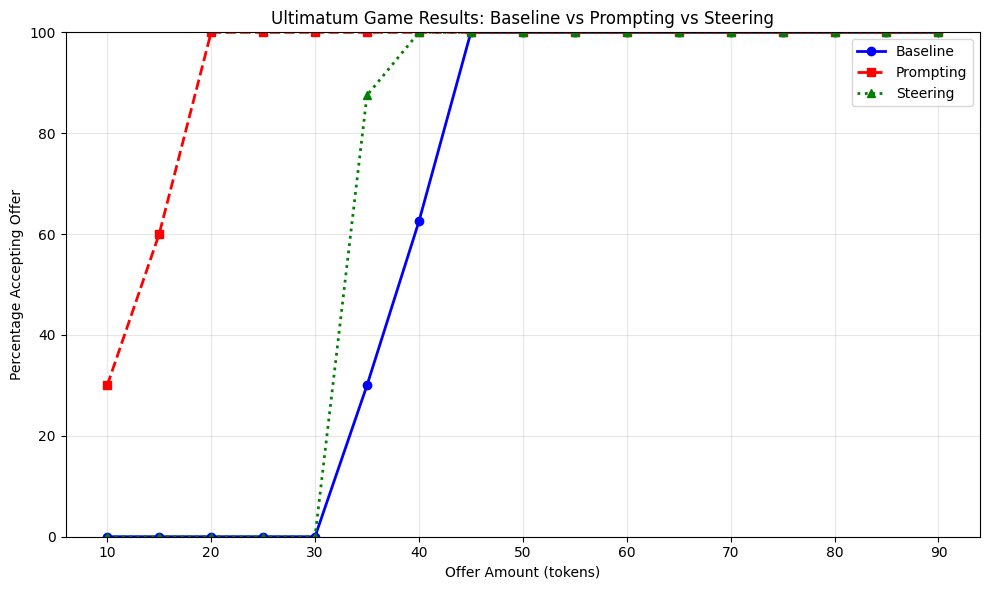

Plot created successfully from summary data!


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_ultimatum_choices(directory=None):
    # If no directory specified, find the most recent results folder
    if directory is None:
        base_dir = "mech_interp_games/ultimatum_game"
        if os.path.exists(base_dir):
            # Find all results directories with timestamps
            results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
            if results_dirs:
                # Sort by timestamp (newest first)
                results_dirs.sort(reverse=True)
                directory = os.path.join(base_dir, results_dirs[0])
                print(f"Using most recent results directory: {directory}")
            else:
                print("No results directories found!")
                return
        else:
            print("Base directory not found!")
            return
    
    # Check if summary file exists first (more reliable)
    summary_file = os.path.join(directory, "ultimatum_experiment_summary.csv")
    if os.path.exists(summary_file):
        print("Using summary file for plotting...")
        df = pd.read_csv(summary_file)
        
        # Create plot from summary data
        plt.figure(figsize=(10, 6))
        plt.plot(df['offer'], df['accept_percent_baseline'], 
                 marker='o', linestyle='-', linewidth=2, markersize=6,
                 label='Baseline', color='blue')
        plt.plot(df['offer'], df['accept_percent_prompting'], 
                 marker='s', linestyle='--', linewidth=2, markersize=6,
                 label='Prompting', color='red')
        plt.plot(df['offer'], df['accept_percent_steering'], 
                 marker='^', linestyle=':', linewidth=2, markersize=6,
                 label='Steering', color='green')
        
        plt.xlabel("Offer Amount (tokens)")
        plt.ylabel("Percentage Accepting Offer")
        plt.title("Ultimatum Game Results: Baseline vs Prompting vs Steering")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 100)
        
        plt.tight_layout()
        plt.show()
        
        print("Plot created successfully from summary data!")
        return
    
    # Fallback to individual files if summary doesn't exist
    print("Summary file not found, processing individual files...")
    
    # Identify all relevant files
    files = sorted([f for f in os.listdir(directory) if f.startswith("ultimatum_") and f.endswith(".csv") and "summary" not in f])

    # Data storage for three conditions
    baseline_data = {}
    prompting_data = {}
    steering_data = {}

    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Compute percentage of "Accept"
        total_choices = len(df)
        accept_count = (df["answer.ultimatum_response"] == "Accept").sum()
        accept_percentage = (accept_count / total_choices) * 100
        
        # Extract iteration number from filename
        iteration = int(file.split("_")[-1].split(".")[0])
        
        # Store in appropriate dictionary based on condition
        if "baseline" in file:
            baseline_data[iteration] = accept_percentage
        elif "prompting" in file:
            prompting_data[iteration] = accept_percentage
        elif "steering" in file:
            steering_data[iteration] = accept_percentage

    # Sort by iteration number
    baseline_data = dict(sorted(baseline_data.items()))
    prompting_data = dict(sorted(prompting_data.items()))
    steering_data = dict(sorted(steering_data.items()))

    print(f"Data collected - Baseline: {baseline_data}, Prompting: {prompting_data}, Steering: {steering_data}")

    # Create simple plot
    plt.figure(figsize=(10, 6))
    
    # Plot the three conditions
    plt.plot(baseline_data.keys(), baseline_data.values(), 
             marker="o", linestyle="-", linewidth=2, markersize=6,
             label="Baseline", color='blue')
    
    plt.plot(prompting_data.keys(), prompting_data.values(), 
             marker="s", linestyle="--", linewidth=2, markersize=6,
             label="Prompting", color='red')
    
    plt.plot(steering_data.keys(), steering_data.values(), 
             marker="^", linestyle=":", linewidth=2, markersize=6,
             label="Steering", color='green')

    plt.xlabel("Offer Amount (tokens)")
    plt.ylabel("Percentage Accepting Offer")
    plt.title("Ultimatum Game Results: Baseline vs Prompting vs Steering")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    print("Plot created successfully from individual files!")

# Example usage:
plot_ultimatum_choices()  # Automatically uses the most recent results directory
